# Personal Loan Default: Baseline to Feature Engineering

This notebook develops an interview-ready classification workflow for predicting `default_flag`.

The work is deliberately split into two stages:

1. **Baseline:** careful data checks, a fixed holdout set, basic preprocessing, and a plain logistic-regression model with no feature engineering.
2. **Extensions:** economically interpretable features, L1-regularized logistic regression, random-forest feature selection, and gradient boosting.

The baseline is the reference point. Later complexity is useful only when it improves validation performance or produces a clearer decision rule.

## 1. Setup and modeling principles

This is an imbalanced binary-classification problem, so accuracy alone is misleading. We report:

- **Average precision (PR-AUC):** primary model-ranking metric because defaults are rare.
- **ROC-AUC:** overall ranking quality.
- **Recall:** fraction of actual defaults identified.
- **Precision:** fraction of predicted defaults that actually default.
- **F1:** balance between precision and recall.
- **Balanced accuracy:** gives equal weight to both classes.

All preprocessing is kept inside scikit-learn pipelines. This ensures that imputation, scaling, encoding, feature engineering, and feature selection are learned only from each training fold.

In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

## 2. Load and understand the data

The CSV is expected to be in the same folder as this notebook. Keeping the path relative makes the project portable.

In [3]:
DATA_PATH = Path("india_personal_loan_default_risk_2026.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.name}. Start Jupyter in the SqptInterview folder "
        "or update DATA_PATH."
    )

credit = pd.read_csv(DATA_PATH)
print(f"Rows: {credit.shape[0]:,}")
print(f"Columns: {credit.shape[1]:,}")
credit.head()

Rows: 25,000
Columns: 22


,applicant_id,age,gender,marital_status,city_tier,state,employment_type,bank_account_vintage_years,monthly_income_inr,existing_loans_count,existing_emi_monthly_inr,credit_utilization_ratio_pct,num_credit_inquiries_last_6m,late_payments_last_12m,loan_amount_requested_inr,loan_tenure_months,loan_purpose,collateral_provided,cibil_score,interest_rate_offered_pct,default_risk_score,default_flag
0,APP106868,22,Male,Single,Tier 3,Haryana,Salaried - PSU,0.5000,12000,1,"1,700.0000",31.4000,2.0000,0,149000,48,Personal Expense,No,649,24.8400,1.6700,0
1,APP124016,35,Female,Divorced,Tier 2,Gujarat,Salaried - Private,0.5000,32500,3,"11,500.0000",47.6000,0.0000,1,156000,60,Personal Expense,No,538,25.2500,4.4700,0
2,APP109668,41,Male,Married,Tier 2,Uttar Pradesh,Salaried - Government,2.8000,52500,0,"6,000.0000",51.8000,0.0000,0,70000,36,Wedding,No,636,20.4600,0.1900,0
3,APP113640,29,Female,Married,Tier 2,Kerala,Salaried - PSU,0.7000,15500,1,"1,900.0000",12.2000,0.0000,1,108000,48,Education,No,721,15.2700,0.2600,0
4,APP114018,31,Male,Married,Tier 1,Punjab,Self-Employed Professional,4.7000,269600,2,"50,800.0000",50.3000,0.0000,2,466000,24,Education,No,586,25.5200,2.1000,0


In [4]:
credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   applicant_id                  25000 non-null  str    
 1   age                           25000 non-null  int64  
 2   gender                        25000 non-null  str    
 3   marital_status                25000 non-null  str    
 4   city_tier                     25000 non-null  str    
 5   state                         25000 non-null  str    
 6   employment_type               25000 non-null  str    
 7   bank_account_vintage_years    24625 non-null  float64
 8   monthly_income_inr            25000 non-null  int64  
 9   existing_loans_count          25000 non-null  int64  
 10  existing_emi_monthly_inr      24500 non-null  float64
 11  credit_utilization_ratio_pct  25000 non-null  float64
 12  num_credit_inquiries_last_6m  24750 non-null  float64
 13  late_payment

In [5]:
credit.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
applicant_id,25000,25000,APP106868,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,"25,000.0000",NaN,NaN,NaN,35.3035,8.5613,21.0000,29.0000,35.0000,41.0000,65.0000
gender,25000,3,Male,14928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,25000,4,Married,14558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_tier,25000,3,Tier 1,9978,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,25000,15,Gujarat,1750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,25000,5,Salaried - Private,11258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bank_account_vintage_years,"24,625.0000",NaN,NaN,NaN,3.9996,3.9006,0.5000,1.1000,2.8000,5.5000,25.0000
monthly_income_inr,"25,000.0000",NaN,NaN,NaN,"54,832.4280","38,347.4882","12,000.0000","29,500.0000","45,100.0000","68,700.0000","727,000.0000"
existing_loans_count,"25,000.0000",NaN,NaN,NaN,1.1037,1.0514,0.0000,0.0000,1.0000,2.0000,6.0000


### Data-quality checks

Before studying relationships, check uniqueness, missingness, plausible ranges, and target balance. These checks often expose more important issues than a sophisticated model.

In [6]:
quality_checks = pd.Series({
    "duplicate_rows": credit.duplicated().sum(),
    "duplicate_applicant_ids": credit["applicant_id"].duplicated().sum(),
    "missing_applicant_ids": credit["applicant_id"].isna().sum(),
    "target_missing": credit["default_flag"].isna().sum(),
    "target_invalid": (~credit["default_flag"].isin([0, 1])).sum(),
    "age_outside_18_100": (~credit["age"].between(18, 100)).sum(),
    "income_nonpositive": (credit["monthly_income_inr"] <= 0).sum(),
    "loan_amount_nonpositive": (credit["loan_amount_requested_inr"] <= 0).sum(),
    "tenure_nonpositive": (credit["loan_tenure_months"] <= 0).sum(),
    "utilization_outside_0_100": (~credit["credit_utilization_ratio_pct"].between(0, 100)).sum(),
    "cibil_outside_300_900": (~credit["cibil_score"].between(300, 900)).sum(),
})
quality_checks.to_frame("count")

,count
duplicate_rows,0
duplicate_applicant_ids,0
missing_applicant_ids,0
target_missing,0
target_invalid,0
age_outside_18_100,0
income_nonpositive,0
loan_amount_nonpositive,0
tenure_nonpositive,0
utilization_outside_0_100,0


In [7]:
missing_summary = (
    credit.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missing_count", "mean": "missing_rate"})
    .query("missing_count > 0")
    .sort_values("missing_rate", ascending=False)
)
missing_summary

,missing_count,missing_rate
existing_emi_monthly_inr,500.0000,0.0200
bank_account_vintage_years,375.0000,0.0150
num_credit_inquiries_last_6m,250.0000,0.0100


In [8]:
target_summary = (
    credit["default_flag"]
    .value_counts(dropna=False)
    .rename_axis("default_flag")
    .to_frame("count")
)
target_summary["rate"] = target_summary["count"] / len(credit)
target_summary

,count,rate
default_flag,,
0,23465,0.9386
1,1535,0.0614


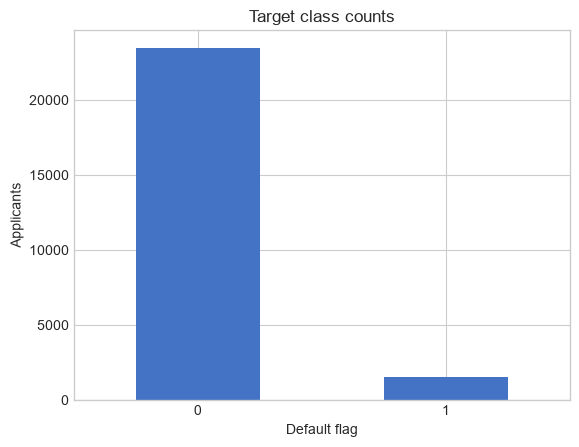

In [9]:
ax = credit["default_flag"].value_counts().sort_index().plot.bar(color="#4472C4")
ax.set(title="Target class counts", xlabel="Default flag", ylabel="Applicants")
ax.tick_params(axis="x", rotation=0)
plt.show()

### Missingness and the target

Missing values may be random, operational, or informative. Compare the default rate for rows where each feature is missing with rows where it is observed. This does not prove a causal relationship, but it indicates whether a missingness flag may help prediction.

In [10]:
missing_columns = credit.columns[credit.isna().any()].tolist()
missing_target_rows = []

for column in missing_columns:
    comparison = (
        credit.assign(is_missing=credit[column].isna())
        .groupby("is_missing")["default_flag"]
        .agg(count="size", defaults="sum", default_rate="mean")
        .reset_index()
    )
    comparison.insert(0, "feature", column)
    missing_target_rows.append(comparison)

missing_vs_target = pd.concat(missing_target_rows, ignore_index=True)
missing_vs_target

,feature,is_missing,count,defaults,default_rate
0,bank_account_vintage_years,False,24625,1508,0.0612
1,bank_account_vintage_years,True,375,27,0.0720
2,existing_emi_monthly_inr,False,24500,1500,0.0612
3,existing_emi_monthly_inr,True,500,35,0.0700
4,num_credit_inquiries_last_6m,False,24750,1524,0.0616
5,num_credit_inquiries_last_6m,True,250,11,0.0440


### Numerical relationships

Correlation is a useful screen, not a complete description. It captures only linear relationships and can be distorted by outliers or constructed variables.

In [11]:
numeric_corr = credit.select_dtypes(include=np.number).corr()
target_correlations = (
    numeric_corr["default_flag"]
    .drop("default_flag")
    .sort_values(key=abs, ascending=False)
)
target_correlations.to_frame("correlation_with_default")

,correlation_with_default
default_risk_score,0.4840
cibil_score,-0.3099
late_payments_last_12m,0.2406
credit_utilization_ratio_pct,0.1831
interest_rate_offered_pct,0.1143
existing_loans_count,0.0802
loan_amount_requested_inr,0.0605
existing_emi_monthly_inr,0.0600
num_credit_inquiries_last_6m,0.0575
bank_account_vintage_years,-0.0469


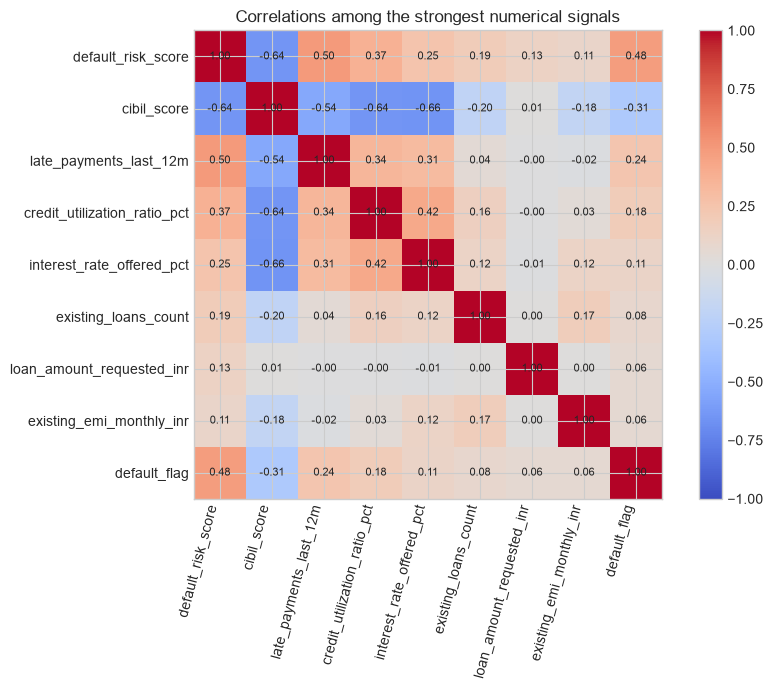

In [12]:
top_numeric = target_correlations.head(8).index.tolist() + ["default_flag"]
plt.figure(figsize=(10, 7))
corr_subset = credit[top_numeric].corr()
image = plt.imshow(corr_subset, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(image, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_subset)), corr_subset.columns, rotation=75, ha="right")
plt.yticks(range(len(corr_subset)), corr_subset.index)
for row in range(len(corr_subset)):
    for column in range(len(corr_subset)):
        plt.text(column, row, f"{corr_subset.iloc[row, column]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Correlations among the strongest numerical signals")
plt.tight_layout()
plt.show()

### Categorical relationships

For each category, inspect both the number of observations and the default rate. Very small groups can produce unstable rates and may need grouping or regularization.

In [13]:
categorical_columns = credit.select_dtypes(exclude=np.number).columns.drop("applicant_id")

categorical_target_tables = {}
for column in categorical_columns:
    table = (
        credit.groupby(column, dropna=False)["default_flag"]
        .agg(count="size", defaults="sum", default_rate="mean")
        .sort_values("default_rate", ascending=False)
    )
    categorical_target_tables[column] = table
    print(f"\n{column}")
    display(table)


gender


,count,defaults,default_rate
gender,,,
Other,485,31,0.0639
Male,14928,927,0.0621
Female,9587,577,0.0602



marital_status


,count,defaults,default_rate
marital_status,,,
Divorced,1525,106,0.0695
Married,14558,889,0.0611
Single,7907,480,0.0607
Widowed,1010,60,0.0594



city_tier


...

,count,defaults,default_rate
employment_type,,,
Business Owner,3700,275,0.0743
Salaried - Government,3806,255,0.0670
Salaried - Private,11258,660,0.0586
Salaried - PSU,2488,138,0.0555
Self-Employed Professional,3748,207,0.0552



loan_purpose


,count,defaults,default_rate
loan_purpose,,,
Debt Consolidation,2470,163,0.0660
Wedding,3462,225,0.0650
Vehicle Purchase,2475,155,0.0626
Personal Expense,5600,342,0.0611
Business Expansion,2016,122,0.0605
Home Renovation,3291,197,0.0599
Education,2447,146,0.0597
Medical Emergency,3239,185,0.0571



collateral_provided


,count,defaults,default_rate
collateral_provided,,,
No,19535,1339,0.0685
Yes,5465,196,0.0359


## 3. Define the holdout set and leakage policy

`applicant_id` is an identifier, not a generalizable predictor, so it is excluded.

`default_risk_score` is a potential leakage variable. Its name and strong relationship with the target suggest it may be an existing model score or may have been constructed using information unavailable at application time. The primary analysis excludes it until its provenance is confirmed.

`interest_rate_offered_pct` should also be discussed in an interview: it is valid only if the prediction is made after the rate is offered. We retain it here, but this assumption must be stated.

The split is stratified so the rare default class has approximately the same prevalence in training and test data.

In [14]:
TARGET = "default_flag"
ID_COLUMNS = ["applicant_id"]
LEAKAGE_CANDIDATES = ["default_risk_score"]

X = credit.drop(columns=[TARGET, *ID_COLUMNS, *LEAKAGE_CANDIDATES])
y = credit[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "default_count": [y_train.sum(), y_test.sum()],
    "default_rate": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])
split_summary

,rows,default_count,default_rate
train,20000,1228,0.0614
test,5000,307,0.0614


## 4. Baseline preprocessing

The baseline deliberately contains **no feature engineering and no feature selection**.

- Numerical features: median imputation, then standardization.
- Categorical features: most-frequent imputation, then one-hot encoding.
- Model: ordinary logistic regression.

All categorical variables, including `city_tier`, are one-hot encoded. This avoids imposing an unverified linear spacing between Tier 1, Tier 2, and Tier 3 in the baseline.

In [16]:
def make_preprocessor(*, dense=False, scale_numeric=True):
    # Discover numerical and categorical columns by dtype.
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=not dense,
            ),
        ),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, selector(dtype_include=np.number)),
        ("categorical", categorical_pipeline, selector(dtype_exclude=np.number)),
    ])


baseline_preprocessor = make_preprocessor()

dummy_pipeline = Pipeline([
    ("preprocess", clone(baseline_preprocessor)),
    ("model", DummyClassifier(strategy="prior")),
])

baseline_logistic = Pipeline([
    ("preprocess", clone(baseline_preprocessor)),
    ("model", LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE)),
])

### Reusable cross-validation comparison

The test set remains untouched. Models are compared using stratified cross-validation on the training set only.

In [17]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}


def evaluate_model_cv(name, estimator, X_data=X_train, y_data=y_train):
    # Return mean and standard deviation for each cross-validation metric.
    scores = cross_validate(
        estimator,
        X_data,
        y_data,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    result = {"model": name, "fit_time_seconds": scores["fit_time"].mean()}
    for metric in scoring:
        result[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        result[f"{metric}_std"] = scores[f"test_{metric}"].std()
    return result


baseline_results = [
    evaluate_model_cv("Dummy classifier", dummy_pipeline),
    evaluate_model_cv("Baseline logistic", baseline_logistic),
]

pd.DataFrame(baseline_results).set_index("model").T

model,Dummy classifier,Baseline logistic
fit_time_seconds,0.0450,0.0620
accuracy_mean,0.9386,0.9420
accuracy_std,0.0001,0.0026
balanced_accuracy_mean,0.5000,0.5688
balanced_accuracy_std,0.0000,0.0148
precision_mean,0.0000,0.6198
precision_std,0.0000,0.0868
recall_mean,0.0000,0.1433
recall_std,0.0000,0.0291
f1_mean,0.0000,0.2323


### Inspect the baseline coefficients

Logistic-regression coefficients are directional associations after preprocessing. They do not establish causality. One-hot categories are interpreted relative to the omitted reference encoded by the model intercept and the other included categories.

In [16]:
baseline_logistic.fit(X_train, y_train)

baseline_feature_names = baseline_logistic.named_steps["preprocess"].get_feature_names_out()
baseline_coefficients = pd.Series(
    baseline_logistic.named_steps["model"].coef_.ravel(),
    index=baseline_feature_names,
    name="coefficient",
).sort_values()

pd.concat([
    baseline_coefficients.head(10),
    baseline_coefficients.tail(10),
]).to_frame()

,coefficient
categorical__collateral_provided_Yes,-1.0838
numeric__cibil_score,-1.0794
numeric__monthly_income_inr,-1.0311
categorical__gender_Female,-0.5296
categorical__city_tier_Tier 3,-0.4988
categorical__employment_type_Salaried - PSU,-0.4703
categorical__gender_Male,-0.4660
categorical__city_tier_Tier 1,-0.4402
categorical__city_tier_Tier 2,-0.4107
categorical__marital_status_Single,-0.3944


## 5. Feature engineering

The engineered features are small in number and have direct credit-risk interpretations:

- `loan_to_annual_income`: requested principal relative to annual income.
- `emi_to_income`: existing monthly repayment burden relative to monthly income.
- `loan_amount_per_month`: requested principal divided by requested tenure. This is not a true amortized payment, but it is a simple burden proxy.
- `credit_stress_mean`: average of directionally aligned, standardized credit signals. Higher utilization, more late payments, more inquiries, and lower CIBIL scores all increase the index.
- Missingness flags for fields with incomplete observations.

The stress-index means and standard deviations are learned in `fit()`, so each validation fold uses only its own training data. Raw variables are retained alongside engineered features; later regularization or tree models can decide whether the additions help.

In [17]:
class CreditFeatureEngineer(BaseEstimator, TransformerMixin):
    # Add interpretable credit ratios, missingness flags, and a stress index.

    stress_columns = [
        "credit_utilization_ratio_pct",
        "late_payments_last_12m",
        "num_credit_inquiries_last_6m",
        "cibil_score",
    ]
    inverse_stress_columns = {"cibil_score"}
    missing_flag_columns = [
        "existing_emi_monthly_inr",
        "bank_account_vintage_years",
        "num_credit_inquiries_last_6m",
    ]

    def fit(self, X, y=None):
        X = X.copy()
        stress = X[self.stress_columns].astype(float)
        self.stress_means_ = stress.mean()
        self.stress_stds_ = stress.std(ddof=0).replace(0, 1)
        return self

    def transform(self, X):
        X = X.copy()

        monthly_income = X["monthly_income_inr"].replace(0, np.nan)
        tenure = X["loan_tenure_months"].replace(0, np.nan)

        X["loan_to_annual_income"] = (
            X["loan_amount_requested_inr"] / (12 * monthly_income)
        )
        X["emi_to_income"] = X["existing_emi_monthly_inr"] / monthly_income
        X["loan_amount_per_month"] = X["loan_amount_requested_inr"] / tenure

        for column in self.missing_flag_columns:
            X[f"{column}_was_missing"] = X[column].isna().astype(int)

        stress = (X[self.stress_columns].astype(float) - self.stress_means_) / self.stress_stds_
        for column in self.inverse_stress_columns:
            stress[column] = -stress[column]
        X["credit_stress_mean"] = stress.mean(axis=1, skipna=True)

        return X


engineered_logistic = Pipeline([
    ("features", CreditFeatureEngineer()),
    ("preprocess", make_preprocessor()),
    ("model", LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE)),
])

engineered_result = evaluate_model_cv("Engineered logistic", engineered_logistic)
pd.DataFrame([*baseline_results, engineered_result]).set_index("model")

,fit_time_seconds,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
model,,,,,,,,,,,,,,,
Dummy classifier,0.0542,0.9386,0.0001,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.0614,0.0001
Baseline logistic,0.0815,0.9420,0.0026,0.5688,0.0148,0.6198,0.0868,0.1433,0.0291,0.2323,0.0433,0.8534,0.0167,0.3697,0.0459
Engineered logistic,0.0962,0.9423,0.0028,0.5750,0.0123,0.6215,0.0891,0.1564,0.0235,0.2496,0.0361,0.8590,0.0188,0.3827,0.0501


## 6. L1-regularized logistic regression

For classification, the direct analogue of Lasso is logistic regression with an **L1 penalty**. L1 regularization shrinks some coefficients exactly to zero, giving a sparse and relatively interpretable model.

The regularization strength `C` is selected using training-set cross-validation and average precision. Smaller `C` means stronger regularization.

In [18]:
l1_logistic = Pipeline([
    ("features", CreditFeatureEngineer()),
    ("preprocess", make_preprocessor()),
    (
        "model",
        LogisticRegression(
            solver="saga",
            l1_ratio=1.0,
            max_iter=5_000,
            random_state=RANDOM_STATE,
        ),
    ),
])

l1_search = GridSearchCV(
    estimator=l1_logistic,
    param_grid={"model__C": [0.01, 0.03, 0.1, 0.3, 1.0]},
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
    refit=True,
    return_train_score=True,
)
l1_search.fit(X_train, y_train)

print("Best C:", l1_search.best_params_["model__C"])
print("Best cross-validated average precision:", round(l1_search.best_score_, 4))

l1_search_results = (
    pd.DataFrame(l1_search.cv_results_)[
        ["param_model__C", "mean_train_score", "mean_test_score", "std_test_score", "mean_fit_time"]
    ]
    .sort_values("mean_test_score", ascending=False)
)
l1_search_results

Best C: 0.1
Best cross-validated average precision: 0.3868


,param_model__C,mean_train_score,mean_test_score,std_test_score,mean_fit_time
2,0.1000,0.3908,0.3868,0.0481,0.6031
3,0.3000,0.3945,0.3854,0.0492,1.3928
4,1.0000,0.3953,0.3837,0.0499,4.7850
1,0.0300,0.3836,0.3826,0.0452,0.3731
0,0.0100,0.3682,0.3681,0.0411,0.2323


In [19]:
best_l1_logistic = l1_search.best_estimator_
l1_feature_names = best_l1_logistic.named_steps["preprocess"].get_feature_names_out()
l1_coefficients = pd.Series(
    best_l1_logistic.named_steps["model"].coef_.ravel(),
    index=l1_feature_names,
    name="coefficient",
)

selected_l1_features = (
    l1_coefficients[l1_coefficients.ne(0)]
    .sort_values(key=abs, ascending=False)
    .to_frame()
)

print(f"Selected {len(selected_l1_features)} of {len(l1_coefficients)} transformed features")
selected_l1_features.head(25)

Selected 25 of 59 transformed features


,coefficient
numeric__cibil_score,-0.8965
categorical__collateral_provided_Yes,-0.7408
numeric__emi_to_income,0.4748
numeric__late_payments_last_12m,0.3406
numeric__loan_to_annual_income,0.3312
categorical__employment_type_Business Owner,0.2272
numeric__credit_stress_mean,0.1841
numeric__existing_emi_monthly_inr,0.1072
numeric__monthly_income_inr,-0.0928
numeric__bank_account_vintage_years,-0.0923


## 7. Random forest with impurity-based feature selection

Random forests can model nonlinearities and interactions without manually specifying them. Their impurity-based feature importances measure the total reduction in split impurity attributed to each transformed feature.

The pipeline below uses one random forest inside `SelectFromModel` to retain features with at least the median importance, then fits a second random forest on the selected features. Because selection stays inside the pipeline, it is repeated independently within every cross-validation fold.

Impurity importance can favor continuous or high-cardinality features. Treat it as a screening device and compare it with permutation importance later.

In [20]:
rf_selector_estimator = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_final_estimator = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_selected = Pipeline([
    ("features", CreditFeatureEngineer()),
    ("preprocess", make_preprocessor(scale_numeric=False)),
    (
        "select",
        SelectFromModel(
            estimator=rf_selector_estimator,
            threshold="median",
        ),
    ),
    ("model", rf_final_estimator),
])

rf_result = evaluate_model_cv("RF with impurity selection", rf_selected)
rf_result

{'model': 'RF with impurity selection',
 'fit_time_seconds': np.float64(2.547923707962036),
 'accuracy_mean': np.float64(0.9310500000000002),
 'accuracy_std': np.float64(0.005741080037762941),
 'balanced_accuracy_mean': np.float64(0.6451784462454215),
 'balanced_accuracy_std': np.float64(0.018715134802220704),
 'precision_mean': np.float64(0.4215359051991451),
 'precision_std': np.float64(0.05525981316427661),
 'recall_mean': np.float64(0.31928322548531607),
 'recall_std': np.float64(0.034262911166665945),
 'f1_mean': np.float64(0.3630265418696531),
 'f1_std': np.float64(0.04173717460951598),
 'roc_auc_mean': np.float64(0.8471965838404991),
 'roc_auc_std': np.float64(0.0169626400453937),
 'average_precision_mean': np.float64(0.3503849735362613),
 'average_precision_std': np.float64(0.047828139328970384)}

In [21]:
rf_selected.fit(X_train, y_train)

rf_all_feature_names = rf_selected.named_steps["preprocess"].get_feature_names_out()
rf_support = rf_selected.named_steps["select"].get_support()
rf_selected_feature_names = rf_all_feature_names[rf_support]
rf_importances = pd.Series(
    rf_selected.named_steps["model"].feature_importances_,
    index=rf_selected_feature_names,
    name="impurity_importance",
).sort_values(ascending=False)

print(f"Selected {rf_support.sum()} of {len(rf_support)} transformed features")
rf_importances.head(25).to_frame()

Selected 30 of 59 transformed features


,impurity_importance
numeric__cibil_score,0.1892
numeric__credit_stress_mean,0.1443
numeric__emi_to_income,0.0885
numeric__credit_utilization_ratio_pct,0.0695
numeric__interest_rate_offered_pct,0.0667
numeric__late_payments_last_12m,0.0594
numeric__loan_to_annual_income,0.0466
numeric__existing_emi_monthly_inr,0.0409
numeric__monthly_income_inr,0.0403
numeric__loan_amount_requested_inr,0.0401


## 8. Histogram gradient boosting

Boosting builds trees sequentially, with each new tree correcting errors made by the existing ensemble. Histogram gradient boosting is efficient on medium-sized tabular datasets and can capture nonlinear effects and interactions.

One-hot encoding is made dense for this estimator. `class_weight="balanced"` gives the minority class more influence during fitting, but probability calibration and the operating threshold should still be reviewed before deployment.

In [22]:
boosting_model = Pipeline([
    ("features", CreditFeatureEngineer()),
    ("preprocess", make_preprocessor(dense=True, scale_numeric=False)),
    (
        "model",
        HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=250,
            max_leaf_nodes=15,
            min_samples_leaf=30,
            l2_regularization=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

boosting_result = evaluate_model_cv("Histogram gradient boosting", boosting_model)
boosting_result

{'model': 'Histogram gradient boosting',
 'fit_time_seconds': np.float64(0.8612508296966552),
 'accuracy_mean': np.float64(0.7913),
 'accuracy_std': np.float64(0.007814089838234506),
 'balanced_accuracy_mean': np.float64(0.769346052816734),
 'balanced_accuracy_std': np.float64(0.01213454257802164),
 'precision_mean': np.float64(0.19164139105345654),
 'precision_std': np.float64(0.008042443396984702),
 'recall_mean': np.float64(0.7443172390907582),
 'recall_std': np.float64(0.02168434211837232),
 'f1_mean': np.float64(0.3047520272091628),
 'f1_std': np.float64(0.011407329271575778),
 'roc_auc_mean': np.float64(0.8498421720780867),
 'roc_auc_std': np.float64(0.01597275098654571),
 'average_precision_mean': np.float64(0.35084446215888715),
 'average_precision_std': np.float64(0.038664993592371126)}

## 9. Compare all candidate models

Models are ranked by mean validation average precision. Standard deviations show how stable each estimate is across folds. A small apparent improvement may not be meaningful if it is smaller than fold-to-fold variation.

The tuned L1 model is evaluated again using its selected `C` so every row below is generated by the same cross-validation helper.

In [23]:
l1_result = evaluate_model_cv("L1 logistic", best_l1_logistic)

all_results = pd.DataFrame([
    *baseline_results,
    engineered_result,
    l1_result,
    rf_result,
    boosting_result,
])

result_columns = [
    "model",
    "average_precision_mean",
    "average_precision_std",
    "roc_auc_mean",
    "recall_mean",
    "precision_mean",
    "f1_mean",
    "balanced_accuracy_mean",
    "accuracy_mean",
    "fit_time_seconds",
]

model_comparison = (
    all_results[result_columns]
    .sort_values("average_precision_mean", ascending=False)
    .reset_index(drop=True)
)
model_comparison

,model,average_precision_mean,average_precision_std,roc_auc_mean,recall_mean,precision_mean,f1_mean,balanced_accuracy_mean,accuracy_mean,fit_time_seconds
0,L1 logistic,0.3868,0.0481,0.8612,0.1433,0.6244,0.2330,0.5688,0.9421,0.6094
1,Engineered logistic,0.3827,0.0501,0.8590,0.1564,0.6215,0.2496,0.5750,0.9423,0.0962
2,Baseline logistic,0.3697,0.0459,0.8534,0.1433,0.6198,0.2323,0.5688,0.9420,0.0815
3,Histogram gradient boosting,0.3508,0.0387,0.8498,0.7443,0.1916,0.3048,0.7693,0.7913,0.8613
4,RF with impurity selection,0.3504,0.0478,0.8472,0.3193,0.4215,0.3630,0.6452,0.9311,2.5479
5,Dummy classifier,0.0614,0.0001,0.5000,0.0000,0.0000,0.0000,0.5000,0.9386,0.0542


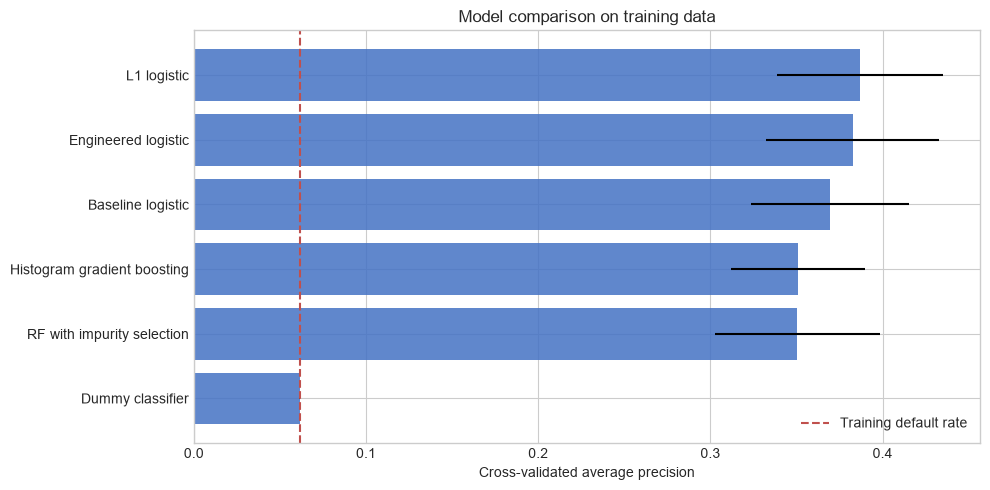

In [24]:
plot_data = model_comparison.sort_values("average_precision_mean")
plt.figure(figsize=(10, 5))
plt.barh(
    plot_data["model"],
    plot_data["average_precision_mean"],
    xerr=plot_data["average_precision_std"],
    color="#4472C4",
    alpha=0.85,
)
plt.axvline(y_train.mean(), color="#C0504D", linestyle="--", label="Training default rate")
plt.xlabel("Cross-validated average precision")
plt.ylabel("")
plt.title("Model comparison on training data")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Select one model and evaluate the untouched test set

The model with the highest cross-validated average precision is selected automatically. This is the **first point** at which the test set is used for performance evaluation.

The default probability threshold of 0.50 is reported first. In a real lending decision, threshold choice should reflect the relative costs of missed defaults and false declines; it should be tuned on validation predictions, not on the test set.

In [25]:
candidate_models = {
    "Dummy classifier": dummy_pipeline,
    "Baseline logistic": baseline_logistic,
    "Engineered logistic": engineered_logistic,
    "L1 logistic": best_l1_logistic,
    "RF with impurity selection": rf_selected,
    "Histogram gradient boosting": boosting_model,
}

selected_model_name = model_comparison.loc[0, "model"]
final_model = clone(candidate_models[selected_model_name])
final_model.fit(X_train, y_train)

test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= 0.50).astype(int)

test_metrics = pd.Series({
    "accuracy": accuracy_score(y_test, test_prediction),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_prediction),
    "precision": precision_score(y_test, test_prediction, zero_division=0),
    "recall": recall_score(y_test, test_prediction, zero_division=0),
    "f1": f1_score(y_test, test_prediction, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_probability),
    "average_precision": average_precision_score(y_test, test_probability),
}, name="test_score")

print("Selected model:", selected_model_name)
test_metrics.to_frame()

Selected model: L1 logistic


,test_score
accuracy,0.9420
balanced_accuracy,0.5673
precision,0.6232
recall,0.1401
f1,0.2287
roc_auc,0.8790
average_precision,0.3989


              precision    recall  f1-score   support

           0      0.946     0.994     0.970      4693
           1      0.623     0.140     0.229       307

    accuracy                          0.942      5000
   macro avg      0.785     0.567     0.599      5000
weighted avg      0.927     0.942     0.924      5000



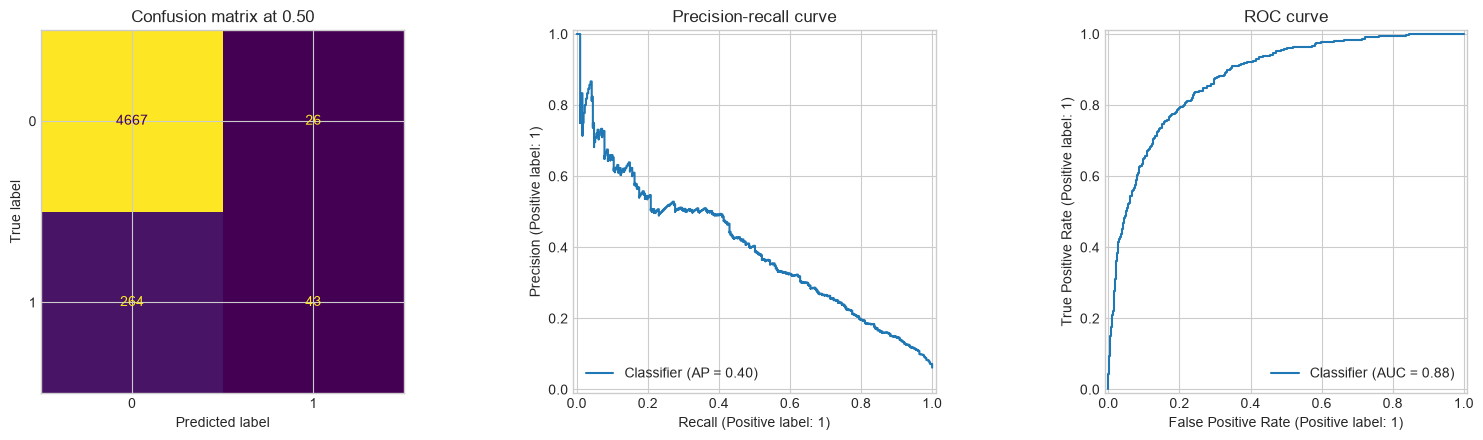

In [26]:
print(classification_report(y_test, test_prediction, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, test_prediction, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix at 0.50")
PrecisionRecallDisplay.from_predictions(y_test, test_probability, ax=axes[1])
axes[1].set_title("Precision-recall curve")
RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[2])
axes[2].set_title("ROC curve")
plt.tight_layout()
plt.show()

### Threshold trade-off

This table is descriptive. Do not select a production threshold from the test set. During an interview, explain that you would use out-of-fold validation probabilities and an explicit cost function to select the threshold, then report the chosen policy once on the test set.

In [27]:
threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.05):
    prediction = (test_probability >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "predicted_default_rate": prediction.mean(),
        "precision": precision_score(y_test, prediction, zero_division=0),
        "recall": recall_score(y_test, prediction, zero_division=0),
        "f1": f1_score(y_test, prediction, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_test, prediction),
    })

threshold_table = pd.DataFrame(threshold_rows)
threshold_table

,threshold,predicted_default_rate,precision,recall,f1,balanced_accuracy
0,0.1000,0.1656,0.2621,0.7068,0.3824,0.7883
1,0.1500,0.1080,0.3296,0.5798,0.4203,0.7513
2,0.2000,0.0738,0.4038,0.4853,0.4408,0.7192
3,0.2500,0.0556,0.4676,0.4235,0.4444,0.6960
4,0.3000,0.0412,0.5097,0.3420,0.4094,0.6602
5,0.3500,0.0320,0.5250,0.2736,0.3597,0.6287
6,0.4000,0.0234,0.5470,0.2085,0.3019,0.5986
7,0.4500,0.0160,0.6000,0.1564,0.2481,0.5748
8,0.5000,0.0138,0.6232,0.1401,0.2287,0.5673
9,0.5500,0.0100,0.6400,0.1042,0.1793,0.5502


## 11. Model-agnostic feature importance

Permutation importance measures the fall in test-set average precision after shuffling one original input column. Unlike transformed impurity importance, it returns to the business-level input columns and can be compared across model types.

This is performed only after final model selection. Importance on the test set is explanatory and should not be used for further model tuning.

In [28]:
permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

permutation_summary = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
permutation_summary

,feature,importance_mean,importance_std
0,monthly_income_inr,0.2521,0.0056
1,existing_emi_monthly_inr,0.2460,0.0085
2,cibil_score,0.2171,0.0150
3,late_payments_last_12m,0.0484,0.0087
4,loan_amount_requested_inr,0.0386,0.0095
5,collateral_provided,0.0294,0.0044
6,num_credit_inquiries_last_6m,0.0070,0.0036
7,employment_type,0.0017,0.0016
8,interest_rate_offered_pct,0.0000,0.0013
9,marital_status,0.0000,0.0000


## 12. Leakage sensitivity check

This optional experiment quantifies how much apparent performance changes when `default_risk_score` is included. A large improvement is not evidence that the feature is valid. It strengthens the need to establish when and how the score was created.

This comparison uses cross-validation on the training population only and does not alter the final test evaluation above.

In [29]:
X_with_score = credit.drop(columns=[TARGET, *ID_COLUMNS])
X_score_train, _, y_score_train, _ = train_test_split(
    X_with_score,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

logistic_with_score = Pipeline([
    ("preprocess", make_preprocessor()),
    ("model", LogisticRegression(max_iter=2_000, random_state=RANDOM_STATE)),
])

leakage_comparison = pd.DataFrame([
    evaluate_model_cv("Baseline without risk score", baseline_logistic),
    evaluate_model_cv(
        "Baseline with risk score",
        logistic_with_score,
        X_data=X_score_train,
        y_data=y_score_train,
    ),
])[
    ["model", "average_precision_mean", "roc_auc_mean", "recall_mean", "precision_mean"]
]
leakage_comparison

,model,average_precision_mean,roc_auc_mean,recall_mean,precision_mean
0,Baseline without risk score,0.3697,0.8534,0.1433,0.6198
1,Baseline with risk score,0.4144,0.8642,0.2183,0.6175


## 13. Interview conclusions

A concise presentation should answer these questions:

1. **What is the target and decision point?** Clarify whether prediction occurs before or after pricing, and whether `default_risk_score` is available without leakage.
2. **What did the data checks reveal?** Report target imbalance, missingness, duplicate checks, implausible values, and important segment patterns.
3. **How strong is the simplest defensible baseline?** Compare logistic regression with the dummy benchmark using cross-validated PR-AUC and ROC-AUC.
4. **Did feature engineering help?** Show whether a few explainable burden and credit-stress features improved validation performance.
5. **Did nonlinear models earn their complexity?** Compare performance gains with interpretability, stability, and runtime.
6. **What errors matter?** Explain false negatives and false positives, then connect threshold choice to business costs.
7. **What remains uncertain?** Discuss leakage, temporal validation, probability calibration, fairness across groups, and distribution drift.

For a real lending application, the next methodological improvements would be a time-based holdout, calibration analysis, subgroup performance checks, and threshold selection from an explicit cost matrix.